# 01 — Dota 2 Draft 数据探索（EDA）

**项目目标：** 将来根据双方十个英雄选择和游戏版本，预测 Radiant 是否获胜。

这份 notebook 只负责探索和验证数据。它要回答四个问题：

1. 数据是否完整、唯一、格式正确？
2. 目标变量 `radiant_win` 是否平衡？
3. 比赛时间、版本和英雄选择如何分布？
4. 哪些字段可以在未来使用，哪些字段会造成数据泄漏？

> **范围限制：** 本 notebook 不导入 scikit-learn，不创建特征矩阵，不划分实际训练文件，也不训练任何模型。

## 如何阅读这份 notebook

每一节先说明“为什么做”，再运行代码，最后解释应该如何理解输出。对于初级数据科学项目，清楚说明决策通常比堆叠复杂方法更加重要。

图表标题使用英文，避免不同电脑缺少中文字体时出现方框；解释文字仍然使用中文。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
COLORS = {
    "radiant": "#2A9D8F",
    "dire": "#E76F51",
    "neutral": "#457B9D",
}

print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

pandas: 3.0.3
NumPy: 2.5.1


## 1. 读取数据

`Path` 让路径代码同时支持两种常见运行方式：从项目根目录运行，或从 `notebooks/` 目录运行。`parse_dates` 会在读取时把比赛时间转换成真正的日期类型，方便后面的排序和按年统计。

In [2]:
current_directory = Path.cwd().resolve()
root_candidates = [current_directory, current_directory.parent]
project_root = next(
    (candidate for candidate in root_candidates if (candidate / "data" / "processed").exists()),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the project root. Run from dota2-ml-portfolio/ or notebooks/."
    )

data_path = project_root / "data" / "processed" / "dota2_matches_sample_30000.csv"
if not data_path.exists():
    raise FileNotFoundError(f"Missing sample file: {data_path}")

df = pd.read_csv(data_path, parse_dates=["match_start_date_time"])

print(f"Project root: {project_root}")
print(f"Data file: {data_path.relative_to(project_root)}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

Project root: /Users/jeffreyqin/Documents/New project/dota2-ml-portfolio
Data file: data/processed/dota2_matches_sample_30000.csv
Loaded: 30,000 rows x 25 columns


## 2. 第一眼检查：一行和一列分别代表什么？

- **一行**：一场职业 Dota 2 比赛。
- **英雄 ID 列**：未来模型的候选输入。
- **英雄名称列**：只方便人阅读，与对应 ID 重复。
- **`radiant_win`**：未来要预测的目标，不能放进输入特征。

先看总体规模和几行真实数据，可以尽早发现分隔错位、日期解析失败或列名异常。

In [3]:
overview = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "memory_mb",
            "first_match",
            "last_match",
        ],
        "value": [
            f"{len(df):,}",
            df.shape[1],
            f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}",
            df["match_start_date_time"].min(),
            df["match_start_date_time"].max(),
        ],
    }
)

display(overview)
display(df.head(3))

,metric,value
0,rows,"30,000"
1,columns,25
2,memory_mb,21.17
3,first_match,2011-08-17 00:00:00
4,last_match,2024-10-15 01:28:24


,match_id,match_start_date_time,game_version_id,game_version,radiant_player_1_hero_id,radiant_player_1_hero,radiant_player_2_hero_id,radiant_player_2_hero,radiant_player_3_hero_id,radiant_player_3_hero,radiant_player_4_hero_id,radiant_player_4_hero,radiant_player_5_hero_id,radiant_player_5_hero,dire_player_1_hero_id,dire_player_1_hero,dire_player_2_hero_id,dire_player_2_hero,dire_player_3_hero_id,dire_player_3_hero,dire_player_4_hero_id,dire_player_4_hero,dire_player_5_hero_id,dire_player_5_hero,radiant_win
0,11048,2011-08-17,11,6.72f,18,Sven,25,Lina,69,Doom,53,Nature's Prophet,17,Storm Spirit,33,Enigma,5,Crystal Maiden,1,Anti-Mage,16,Sand King,11,Shadow Fiend,True
1,11151,2011-08-17,11,6.72f,31,Lich,1,Anti-Mage,38,Beastmaster,21,Windranger,5,Crystal Maiden,66,Chen,40,Venomancer,30,Witch Doctor,53,Nature's Prophet,36,Necrophos,False
2,11323,2011-08-18,11,6.72f,18,Sven,31,Lich,45,Pugna,25,Lina,10,Morphling,38,Beastmaster,66,Chen,63,Weaver,51,Clockwerk,30,Witch Doctor,True


In [4]:
hero_id_columns = [
    f"{side}_player_{slot}_hero_id"
    for side in ("radiant", "dire")
    for slot in range(1, 6)
]
hero_name_columns = [column.removesuffix("_id") for column in hero_id_columns]

column_roles = pd.DataFrame(
    [
        ("match_id", "Tracking/deduplication", "Keep, but do not use as a model input"),
        ("match_start_date_time", "Time split", "Use for chronological splitting, not as a v1 feature"),
        ("game_version_id", "Candidate feature", "Patch changes affect hero balance"),
        ("game_version", "Display only", "Duplicates the patch ID for readability"),
        ("10 *_hero_id columns", "Candidate features", "Known when the draft ends"),
        ("10 *_hero columns", "Display only", "Duplicate hero IDs for readability"),
        ("radiant_win", "Target", "Prediction target; never include among input features"),
    ],
    columns=["column_or_group", "role", "reason"],
)
display(column_roles)

,column_or_group,role,reason
0,match_id,Tracking/deduplication,"Keep, but do not use as a model input"
1,match_start_date_time,Time split,"Use for chronological splitting, not as a v1 feature"
2,game_version_id,Candidate feature,Patch changes affect hero balance
3,game_version,Display only,Duplicates the patch ID for readability
4,10 *_hero_id columns,Candidate features,Known when the draft ends
5,10 *_hero columns,Display only,Duplicate hero IDs for readability
6,radiant_win,Target,Prediction target; never include among input features


## 3. 数据质量检查

数据质量检查是在问：“这 30,000 行是否真的可以安全进入下一阶段？”

这里检查：比赛是否唯一、是否有缺失值、日期是否有效、英雄 ID 是否为正数、每场是否刚好有十个不同英雄，以及目标是否只有两个合法类别。

In [5]:
duplicate_match_ids = int(df["match_id"].duplicated().sum())
missing_cells = int(df.isna().sum().sum())
invalid_dates = int(df["match_start_date_time"].isna().sum())
non_positive_hero_ids = int((df[hero_id_columns] <= 0).sum().sum())
rows_without_ten_unique_heroes = int(
    df[hero_id_columns].nunique(axis=1).ne(10).sum()
)
target_values = set(df["radiant_win"].dropna().unique())
target_is_binary = target_values == {False, True}

quality_checks = pd.DataFrame(
    [
        ("30,000 rows loaded", len(df), 30_000, len(df) == 30_000),
        ("25 columns loaded", df.shape[1], 25, df.shape[1] == 25),
        ("Duplicate match IDs", duplicate_match_ids, 0, duplicate_match_ids == 0),
        ("Missing cells", missing_cells, 0, missing_cells == 0),
        ("Invalid dates", invalid_dates, 0, invalid_dates == 0),
        ("Non-positive hero IDs", non_positive_hero_ids, 0, non_positive_hero_ids == 0),
        (
            "Rows without 10 unique heroes",
            rows_without_ten_unique_heroes,
            0,
            rows_without_ten_unique_heroes == 0,
        ),
        ("Binary target", sorted(target_values), [False, True], target_is_binary),
        (
            "Chronologically sorted",
            df["match_start_date_time"].is_monotonic_increasing,
            True,
            df["match_start_date_time"].is_monotonic_increasing,
        ),
    ],
    columns=["check", "observed", "expected", "passed"],
)
quality_checks["status"] = np.where(quality_checks["passed"], "PASS", "REVIEW")
display(quality_checks.drop(columns="passed"))

assert quality_checks["passed"].all(), "At least one data-quality check failed."
print("All predefined data-quality checks passed.")

,check,observed,expected,status
0,"30,000 rows loaded",30000,30000,PASS
1,25 columns loaded,25,25,PASS
2,Duplicate match IDs,0,0,PASS
3,Missing cells,0,0,PASS
4,Invalid dates,0,0,PASS
5,Non-positive hero IDs,0,0,PASS
6,Rows without 10 unique heroes,0,0,PASS
7,Binary target,"[False, True]","[False, True]",PASS
8,Chronologically sorted,True,True,PASS


All predefined data-quality checks passed.


In [6]:
dtype_summary = (
    df.dtypes.astype(str)
    .reset_index(name="dtype")
    .rename(columns={"index": "column"})
)
dtype_summary["missing"] = [int(df[column].isna().sum()) for column in dtype_summary["column"]]
display(dtype_summary)

,column,dtype,missing
0,match_id,int64,0
1,match_start_date_time,datetime64[us],0
2,game_version_id,int64,0
3,game_version,str,0
4,radiant_player_1_hero_id,int64,0
5,radiant_player_1_hero,str,0
6,radiant_player_2_hero_id,int64,0
7,radiant_player_2_hero,str,0
8,radiant_player_3_hero_id,int64,0
9,radiant_player_3_hero,str,0


**如何理解：** 全部通过不代表数据“完美”，只表示它满足当前定义的基本规则。以后如果更改预测时点或加入新的原始字段，必须重新设计检查，而不是盲目复用这张表。

## 4. 目标变量分布

如果某一类别占绝大多数，一个模型即使什么都没学会，只预测多数类别也可能得到很高准确率。因此，训练前必须先建立“多数类别基线”的概念。

,result,matches,share
0,Radiant win,15335,0.511
1,Dire win,14665,0.489


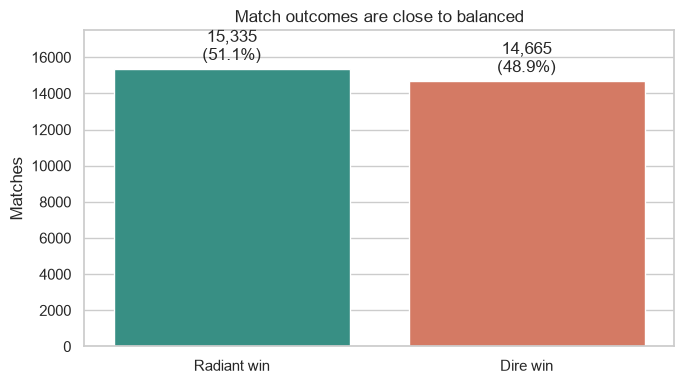

Future majority-class accuracy baseline: 51.1%


In [7]:
target_counts = df["radiant_win"].value_counts().reindex([True, False], fill_value=0)
target_summary = pd.DataFrame(
    {
        "result": ["Radiant win", "Dire win"],
        "matches": [int(target_counts[True]), int(target_counts[False])],
    }
)
target_summary["share"] = target_summary["matches"] / len(df)
display(target_summary)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=target_summary,
    x="result",
    y="matches",
    hue="result",
    palette=[COLORS["radiant"], COLORS["dire"]],
    legend=False,
    ax=ax,
)
ax.set_title("Match outcomes are close to balanced")
ax.set_xlabel("")
ax.set_ylabel("Matches")
ax.set_ylim(0, target_summary["matches"].max() * 1.14)
for index, row in target_summary.iterrows():
    ax.text(
        index,
        row["matches"] + 250,
        f"{row['matches']:,}\n({row['share']:.1%})",
        ha="center",
        va="bottom",
    )
plt.tight_layout()
plt.show()

majority_baseline = target_summary["share"].max()
print(f"Future majority-class accuracy baseline: {majority_baseline:.1%}")

**如何理解：** 两类接近均衡是好消息，但未来不能只报告 Accuracy。概率预测还应该报告 ROC-AUC 和 Log Loss；这一步只是认识目标，并没有训练模型。

## 5. 时间覆盖范围

Dota 2 会持续更新。旧版本中的英雄强度和组合关系可能不适用于新版本，所以时间不是普通的背景信息，而是评估设计的一部分。

,year,matches
0,2011,7
1,2012,45
2,2013,160
3,2014,2134
4,2015,2414
5,2016,2025
6,2017,1808
7,2018,1921
8,2019,2587
9,2020,3087


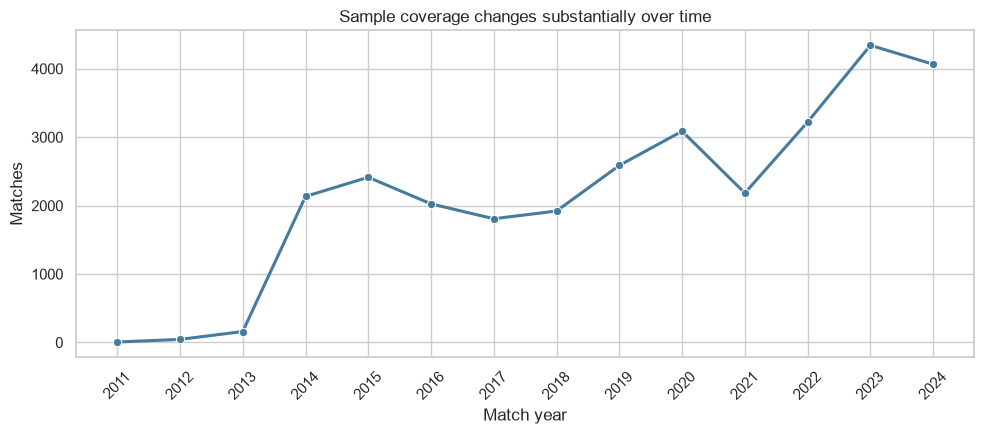

In [8]:
matches_by_year = (
    df.assign(year=df["match_start_date_time"].dt.year)
    .groupby("year", as_index=False)
    .size()
    .rename(columns={"size": "matches"})
)
display(matches_by_year)

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.lineplot(
    data=matches_by_year,
    x="year",
    y="matches",
    marker="o",
    linewidth=2.2,
    color=COLORS["neutral"],
    ax=ax,
)
ax.set_title("Sample coverage changes substantially over time")
ax.set_xlabel("Match year")
ax.set_ylabel("Matches")
ax.set_xticks(matches_by_year["year"])
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

**如何理解：** 各年份样本数并不相同，而且跨度很长。因此未来应按时间切分，而不是把全部比赛随机打散。随机切分可能让相同版本、队伍或赛事同时出现在训练集和测试集中，使测试结果过于乐观。

## 6. 游戏版本分布

`game_version_id` 是计划使用的上下文特征。先检查每个版本的样本量，可以发现稀有版本，并判断版本变化是否会影响后续切分。

The sample contains 156 game patches.


,game_version_id,game_version,matches,share
136,157,7.32d,1193,0.040
154,176,7.37,929,0.031
128,149,7.30e,913,0.030
149,170,7.35b,907,0.030
132,153,7.31d,905,0.030
30,50,6.84c,862,0.029
115,136,7.27d,827,0.028
146,167,7.34d,780,0.026
151,172,7.35d,707,0.024
110,131,7.26c,642,0.021


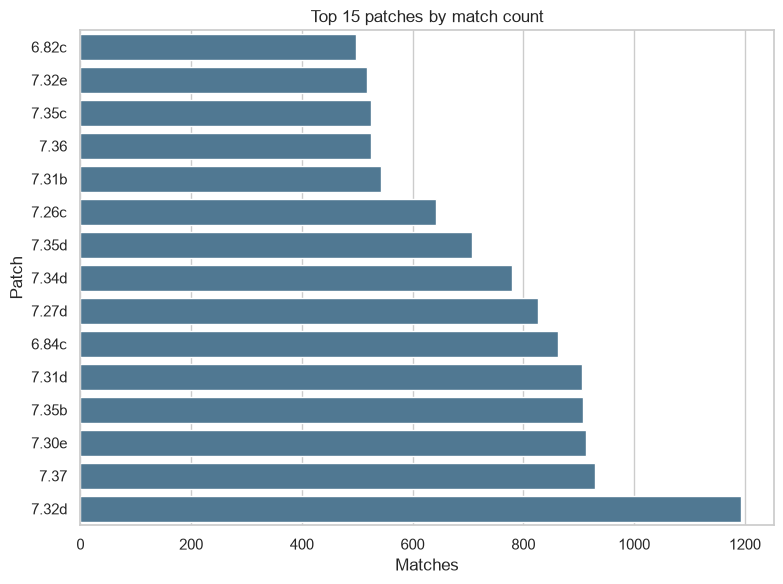

In [9]:
patch_counts = (
    df.groupby(["game_version_id", "game_version"], as_index=False)
    .size()
    .rename(columns={"size": "matches"})
    .sort_values("matches", ascending=False)
)
patch_counts["share"] = patch_counts["matches"] / len(df)
print(f"The sample contains {len(patch_counts)} game patches.")
display(patch_counts.head(15))

top_patches = patch_counts.head(15).sort_values("matches")
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(
    data=top_patches,
    x="matches",
    y="game_version",
    color=COLORS["neutral"],
    ax=ax,
)
ax.set_title("Top 15 patches by match count")
ax.set_xlabel("Matches")
ax.set_ylabel("Patch")
plt.tight_layout()
plt.show()

**如何理解：** 版本样本量不均衡是正常现象。未来可以先把版本 ID 当作类别特征；如果某些版本样本过少，再考虑合并、过滤或仅使用较新的时间窗口。当前阶段不做这些处理。

## 7. 英雄选择频率

原始样本采用“宽格式”：一场比赛有十组英雄列。为了统计英雄出现次数，我们临时把它转换成“长格式”，让每一行代表一次英雄选择。

这个转换只存在于内存，不会覆盖样本 CSV。

In [10]:
pick_frames = []
for side in ("radiant", "dire"):
    for slot in range(1, 6):
        id_column = f"{side}_player_{slot}_hero_id"
        name_column = f"{side}_player_{slot}_hero"
        frame = df[["match_id", id_column, name_column]].rename(
            columns={id_column: "hero_id", name_column: "hero_name"}
        )
        frame["side"] = side.title()
        frame["slot"] = slot
        pick_frames.append(frame)

picks = pd.concat(pick_frames, ignore_index=True)
assert len(picks) == len(df) * 10

print(f"Long-format pick records: {len(picks):,} rows ({len(df):,} matches x 10 heroes)")
display(picks.head())

Long-format pick records: 300,000 rows (30,000 matches x 10 heroes)


,match_id,hero_id,hero_name,side,slot
0,11048,18,Sven,Radiant,1
1,11151,31,Lich,Radiant,1
2,11323,18,Sven,Radiant,1
3,11347,20,Vengeful Spirit,Radiant,1
4,11508,31,Lich,Radiant,1


,hero_id,hero_name,picks,match_share
84,86,Rubick,7332,0.244
104,106,Ember Spirit,4708,0.157
18,19,Tiny,4693,0.156
19,20,Vengeful Spirit,4080,0.136
85,87,Disruptor,3955,0.132
8,9,Mirana,3940,0.131
49,51,Clockwerk,3926,0.131
98,100,Tusk,3917,0.131
6,7,Earthshaker,3797,0.127
72,74,Invoker,3757,0.125


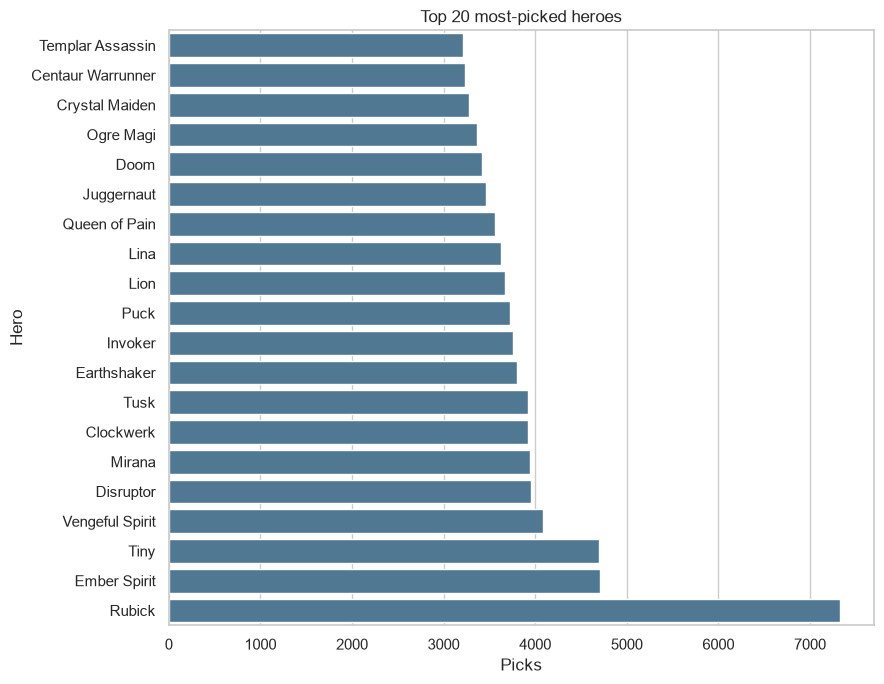

In [11]:
hero_frequency = (
    picks.groupby(["hero_id", "hero_name"], as_index=False)
    .size()
    .rename(columns={"size": "picks"})
    .sort_values("picks", ascending=False)
)
hero_frequency["match_share"] = hero_frequency["picks"] / len(df)

top_heroes = hero_frequency.head(20)
display(top_heroes)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(
    data=top_heroes.sort_values("picks"),
    x="picks",
    y="hero_name",
    color=COLORS["neutral"],
    ax=ax,
)
ax.set_title("Top 20 most-picked heroes")
ax.set_xlabel("Picks")
ax.set_ylabel("Hero")
plt.tight_layout()
plt.show()

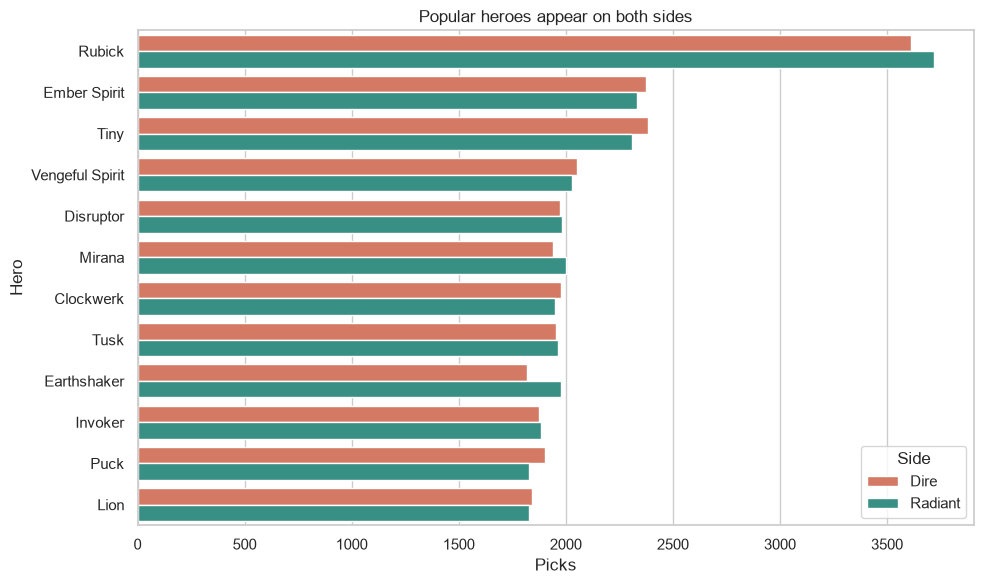

In [12]:
top_hero_names = top_heroes.head(12)["hero_name"]
side_frequency = (
    picks[picks["hero_name"].isin(top_hero_names)]
    .groupby(["hero_name", "side"], as_index=False)
    .size()
    .rename(columns={"size": "picks"})
)
hero_order = top_heroes.head(12)["hero_name"].tolist()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=side_frequency,
    x="picks",
    y="hero_name",
    order=hero_order,
    hue="side",
    palette={"Radiant": COLORS["radiant"], "Dire": COLORS["dire"]},
    ax=ax,
)
ax.set_title("Popular heroes appear on both sides")
ax.set_xlabel("Picks")
ax.set_ylabel("Hero")
ax.legend(title="Side")
plt.tight_layout()
plt.show()

**如何理解：** 英雄频率差异说明类别非常不均匀。未来编码时不能把英雄 ID 当作连续数字——例如 ID 100 并不比 ID 10 “大十倍”。应该使用 one-hot、side-aware 向量或其他类别编码方式。

Radiant 与 Dire 的选择次数接近并不等于胜率相同；本节只看“被选了多少次”，没有进行因果或胜率推断。

## 8. 数据泄漏审计

我们的预测时点是：**选秀完成后、比赛开始前**。只有在这个时点已经存在的信息才有资格成为输入。

In [13]:
leakage_audit = pd.DataFrame(
    [
        ("game_version_id", "Use", "Known before the match and affects hero balance"),
        ("10 hero IDs", "Use", "Known when the draft ends"),
        ("radiant_win", "Target only", "This is the answer to predict"),
        ("match_start_date_time", "Split only", "Supports past-to-future evaluation"),
        ("match_id", "Tracking only", "Arbitrary identifier with no game meaning"),
        ("Hero and patch names", "Display only", "Duplicate the corresponding IDs"),
        ("winner_id", "Exclude: direct leakage", "Directly identifies the winner"),
        ("Duration, first blood, team kills", "Exclude: in/post-match", "Unavailable at prediction time"),
        ("Player K/D/A and net worth", "Exclude: post-match", "Contains information about match results"),
        ("Position, lane, and role", "Exclude: leakage risk", "May be inferred from observed gameplay"),
        ("Team, player, league, and series IDs", "Exclude from v1", "Adds complexity and identity memorization effects"),
    ],
    columns=["field_group", "v1_decision", "reason"],
)
display(leakage_audit)

,field_group,v1_decision,reason
0,game_version_id,Use,Known before the match and affects hero balance
1,10 hero IDs,Use,Known when the draft ends
2,radiant_win,Target only,This is the answer to predict
3,match_start_date_time,Split only,Supports past-to-future evaluation
4,match_id,Tracking only,Arbitrary identifier with no game meaning
5,Hero and patch names,Display only,Duplicate the corresponding IDs
6,winner_id,Exclude: direct leakage,Directly identifies the winner
7,"Duration, first blood, team kills",Exclude: in/post-match,Unavailable at prediction time
8,Player K/D/A and net worth,Exclude: post-match,Contains information about match results
9,"Position, lane, and role",Exclude: leakage risk,May be inferred from observed gameplay


## 9. 规划按时间切分（只规划，不创建训练数据）

下面用排序后的位置提出约 70% / 15% / 15% 的时间切分边界。边界只是下一阶段的候选方案，目前不会写出训练、验证或测试文件。

如果边界日期切在同一天内，同一天的比赛全部放在较早的数据段，避免同一天跨集合。

In [14]:
ordered_dates = df["match_start_date_time"].sort_values().reset_index(drop=True)
train_boundary_candidate = ordered_dates.iloc[int(len(df) * 0.70) - 1]
validation_boundary_candidate = ordered_dates.iloc[int(len(df) * 0.85) - 1]

proposed_split = np.select(
    [
        df["match_start_date_time"] <= train_boundary_candidate,
        df["match_start_date_time"] <= validation_boundary_candidate,
    ],
    ["train", "validation"],
    default="test",
)

split_plan = (
    df.assign(proposed_split=proposed_split)
    .groupby("proposed_split", as_index=False)
    .agg(
        matches=("match_id", "size"),
        first_match=("match_start_date_time", "min"),
        last_match=("match_start_date_time", "max"),
    )
)
split_order = pd.CategoricalDtype(
    categories=["train", "validation", "test"], ordered=True
)
split_plan["proposed_split"] = split_plan["proposed_split"].astype(split_order)
split_plan = split_plan.sort_values("proposed_split")
split_plan["share"] = split_plan["matches"] / len(df)

print(f"Candidate training cutoff: {train_boundary_candidate}")
print(f"Candidate validation cutoff: {validation_boundary_candidate}")
display(split_plan)

Candidate training cutoff: 2022-11-11 00:00:00
Candidate validation cutoff: 2023-11-19 08:14:29


,proposed_split,matches,first_match,last_match,share
1,train,21004,2011-08-17 00:00:00,2022-11-11 00:00:00,0.700
2,validation,4496,2022-11-12 00:00:00,2023-11-19 08:14:29,0.150
0,test,4500,2023-11-19 08:38:55,2024-10-15 01:28:24,0.150


**如何理解：** 时间切分更接近真实使用场景，但仍需要检查边界附近的版本和赛事。最终切分最好落在自然的版本或时间节点，而不是机械追求精确的 70/15/15。

## 10. 自动生成 EDA 小结

下面的小结来自上面的计算结果，而不是手工填写。这样样本更新后，结论也会随 notebook 重新运行而更新。

In [15]:
top_hero = hero_frequency.iloc[0]
radiant_share = float(df["radiant_win"].mean())
all_quality_checks_passed = bool(quality_checks["passed"].all())

summary_text = f'''
### Main EDA findings

- The sample contains **{len(df):,} unique matches and {df.shape[1]} columns**, covering **{df['match_start_date_time'].min():%Y-%m-%d} to {df['match_start_date_time'].max():%Y-%m-%d}**.
- Predefined data-quality checks: **{'all passed' if all_quality_checks_passed else 'review required'}**.
- Radiant wins **{radiant_share:.1%}** of matches; the majority-class baseline is about **{majority_baseline:.1%}**.
- The sample contains **{len(patch_counts)} patches**, so temporal patch drift matters for evaluation.
- The most-picked hero is **{top_hero['hero_name']}**, with **{int(top_hero['picks']):,} picks**.
- Version-one candidate inputs remain: **game patch ID + five Radiant hero IDs + five Dire hero IDs**.
- This notebook **does not train a model or write train/validation/test files**.
'''
display(Markdown(summary_text))


### Main EDA findings

- The sample contains **30,000 unique matches and 25 columns**, covering **2011-08-17 to 2024-10-15**.
- Predefined data-quality checks: **all passed**.
- Radiant wins **51.1%** of matches; the majority-class baseline is about **51.1%**.
- The sample contains **156 patches**, so temporal patch drift matters for evaluation.
- The most-picked hero is **Rubick**, with **7,332 picks**.
- Version-one candidate inputs remain: **game patch ID + five Radiant hero IDs + five Dire hero IDs**.
- This notebook **does not train a model or write train/validation/test files**.


## 下一步（不在本 notebook 中执行）

下一份 notebook 可以命名为 `02_feature_engineering.ipynb`，只完成特征构造：

1. 将英雄 ID 视为类别，而不是连续数字；
2. 用 side-aware 表示保留 Radiant / Dire 信息；
3. 固定基于时间的切分边界；
4. 输出可以被模型读取的特征矩阵和标签；
5. 在完成这些检查后，再单独创建基线模型 notebook。

这种分阶段方式能让 GitHub 审阅者清楚看到：数据理解、泄漏控制、特征工程和建模是四个不同步骤。